# Wind and Solar
## Introduction
This notebook covers the filtering and selection of the gridcells used for wind and solar capacity factor profiles. The capacity factors are pulled from CODERS for 2021. Other capacity factor datasets at different resolutions will work, as long as the required data is provided in the correct format, which includes:
1. Hourly capacity factors for representative wind and solar technologies for a full year
2. Latitude and longitude co-ordinates for each location

### Loading data
The first step is to load the "gridcells" corresponding to the co-ordinates used to calculate the wind/solar capacity factors. The data is provided resolution of 0.625 x 0.5 degrees in a longitude-by-latitude grid. The census area map used in the clustering stage (see Clustering notebook) is used to identify which cells are within the land boundaries of Canada, as well as assigning the gridcells to their respective cluster. The locations and capacities of existing generators are from the __[CODERS](https://coders.cme-emh.ca/login)__ database and preprocessed in a pre-processing step. Finally, Natural Resource Canada's __[Canvec](https://open.canada.ca/data/en/dataset/92dbea79-f644-4a62-b25e-8eb993ca0264)__ power line map is used for filtering gricells based on their distance to the transmission grid.

In [1]:
# Importing packages
import pandas as pd
import geopandas as gpd
import os
from shapely.geometry import Point, Polygon
import numpy as np
import rasterio
from rasterio import features
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize

from helper_functions import download_and_unzip, CODERS_pull, read_api_key

In [2]:
path = os.getcwd()
data_path = os.path.join(path, 'data')
key = read_api_key(data_path)

In [3]:
# Read the gridcell data
if os.path.exists(os.path.join(data_path, 'CODERS', 'gridcell_data.csv')):
    print('Gridcell data already pulled from CODERS, skipping')
    gridcells = pd.read_csv(os.path.join(data_path, 'CODERS', 'gridcell_data.csv'))
else:
    gridcells = CODERS_pull('grid_cell_info', key)
    gridcells.to_csv(os.path.join(data_path, 'CODERS', 'gridcell_data.csv'))

# Create gridcell points
gridcells['geometry'] = gridcells.apply(lambda row: Point(row.longitude, row.latitude), axis=1)
gridcells = gridcells.set_index('grid_cell')
gridcells.index = gridcells.index.astype(str)
gridcells = gpd.GeoDataFrame(geometry=gridcells.geometry, index=gridcells.index, crs='EPSG:4326')

# Saving the point geometry to be used later
gridcells['point_geometry'] = gridcells.geometry

# degree spacing between grid cells
lonDeg = 0.625
latDeg = 0.5
polys = []
# convert grid cell points to grid cell polygons
for index, row in gridcells.iterrows():
    geometry = row.geometry

    x = geometry.x
    y = geometry.y

    min_x = x - lonDeg / 2
    min_y = y - latDeg / 2
    max_x = x + lonDeg / 2
    max_y = y + latDeg / 2

    poly_geom = Polygon([(min_x, min_y),
                         (min_x, max_y),
                         (max_x, max_y),
                         (max_x, min_y),
                         (min_x, min_y)])
    polys.append(poly_geom)
gridcells['poly_geometry'] = polys
gridcells = gpd.GeoDataFrame(gridcells, geometry=gridcells.poly_geometry, index=gridcells.index, crs='EPSG:4326').to_crs('EPSG:3347')

Gridcell data already pulled from CODERS, skipping


In [4]:
# Read wind data
if os.path.exists(os.path.join(data_path, 'CODERS', 'wind_cf_2021.csv')):
    print('Wind CFs already pulled from CODERS, skipping')
    wind_df = pd.read_csv(os.path.join(data_path, 'CODERS', 'wind_cf_2021.csv'))
else:
    wind_df = CODERS_pull('wind_capacity_factor', key, url='year=2021', type='csv')
    wind_df.to_csv(os.path.join(data_path, 'CODERS', 'wind_cf_2021.csv'), index=False)
wind_df = wind_df.set_index(pd.date_range(start='2025-01-01', end='2025-12-31 23:00:00', freq='h')).drop('h',axis=1)
wind_df = wind_df.round(4)

# Read solar data
if os.path.exists(os.path.join(data_path, 'CODERS', 'solar_cf_2021.csv')):
    print('Solar CFs already pulled from CODERS, skipping')
    solar_df = pd.read_csv(os.path.join(data_path, 'CODERS', 'solar_cf_2021.csv'))
else:
    solar_df = CODERS_pull('solar_capacity_factor', key, url='year=2021', type='csv')
    solar_df.to_csv(os.path.join(data_path, 'CODERS', 'solar_cf_2021.csv'), index=False)
solar_df = solar_df.set_index(pd.date_range(start='2025-01-01', end='2025-12-31 23:00:00', freq='h')).drop('h',axis=1)
wind_df = wind_df.round(4)

Wind CFs already pulled from CODERS, skipping
Solar CFs already pulled from CODERS, skipping


In [5]:
# Read cluster shapefile
clusters = gpd.read_feather(os.path.join(path, 'results', 'clustered_zone_data.feather')).to_crs('EPSG:3347')
clusters = clusters[['geometry']]

In [6]:
## Download files
os.makedirs(os.path.join(data_path, 'map_files'), exist_ok=True)
canvec_link = "https://ftp.maps.canada.ca/pub/nrcan_rncan/vector/canvec/shp/Res_MGT/canvec_50K_CA_Res_MGT_shp.zip"
canvec_filepath = os.path.join(data_path, 'map_files', 'CANVEC.zip')
canvec_outpath = os.path.join(data_path, 'map_files', 'CANVEC')
download_and_unzip(canvec_link, canvec_filepath, canvec_outpath)

Download complete
Extracting c:\Users\ndematos\Desktop\pypsa_canada\PyPSA-Canada-National\data\map_files\CANVEC.zip...
Extracted to c:\Users\ndematos\Desktop\pypsa_canada\PyPSA-Canada-National\data\map_files\CANVEC/


In [7]:
# Read transmission map file
transmission_data = gpd.read_file(os.path.join(data_path, 'map_files', 'CANVEC', 'canvec_50K_CA_Res_MGT', 'power_line_1.shp'))
transmission_data = gpd.GeoDataFrame(transmission_data, geometry=transmission_data.geometry, crs='EPSG:4617')

# Filtering out all lines in the remote north
def filter_lat(line):
    return any(coord[1] <= 56 for coord in line.coords)
    
transmission_data = transmission_data[transmission_data['geometry'].apply(lambda geom: filter_lat(geom))]
transmission_data = transmission_data.to_crs('EPSG:3347')

## Existing and Planned solar and wind resources
The existing and planned wind and solar resources are assigned to the closest cells. Option to aggregate generators of the same type, at the same gridcell location. For generators missing capacity factor data at their respective gridcell (displayed below), the nearest cell is chosen. 

In [13]:
# Planned generator data
planned_gens = pd.read_csv(os.path.join(path, 'data', 'planned_projects', 'new_capacity.csv'))
planned_gens = planned_gens[planned_gens.model.isin(['solar_PV', 'wind_ons'])]
planned_gens['geometry'] = planned_gens.apply(lambda row: Point(row.longitude, row.latitude), axis=1)
planned_gens = planned_gens.rename({'build_year': 'previous_renewal_year', 'p_nom': 'unit_installed_capacity', 'model':'gen_type', 'name':'generation_unit_name'}, axis=1)
planned_gens = gpd.GeoDataFrame(planned_gens[['generation_unit_name', 'gen_type', 'previous_renewal_year', 'unit_installed_capacity']], geometry=planned_gens.geometry, index=planned_gens.index, crs='EPSG:4326').to_crs('EPSG:3347')

# Read generator data and filter wind and solar
generator_data = pd.read_csv(os.path.join(path, 'data', 'CODERS', 'generators.csv'), index_col=0)
generator_data = generator_data[generator_data.gen_type.isin(['solar_PV', 'wind_ons'])]
generator_data['geometry'] = generator_data.apply(lambda row: Point(row.longitude, row.latitude), axis=1)
generator_data.loc[(generator_data.previous_renewal_year >= 2025) & (generator_data.start_year < 2025), 'previous_renewal_year'] = 2025 # If the renewal year is greater than 2025 but the start year is before 2025, set the renewal to 2025
generator_data = generator_data.groupby(['generation_unit_name', 'gen_type', 'previous_renewal_year']).first().reset_index()
generator_data = gpd.GeoDataFrame(generator_data[['generation_unit_name', 'gen_type', 'previous_renewal_year', 'unit_installed_capacity']], geometry=generator_data.geometry, index=generator_data.index, crs='EPSG:4326').to_crs('EPSG:3347')
generator_data = pd.concat([generator_data, planned_gens])

# # Assigning closest gridcells
generator_data = gpd.sjoin_nearest(generator_data, gridcells[['geometry']], how='left', distance_col='distance')

# # Assigning closest clusters
generator_data = gpd.sjoin_nearest(generator_data, clusters, how='left')
generator_data

,generation_unit_name,gen_type,previous_renewal_year,unit_installed_capacity,geometry,grid_cell,distance,cluster
0,Adelaide Wind,wind_ons,2014,60.00,POINT (7044047.249 825045.379),1783,0.0,ON_South
1,Aeolus,wind_ons,2003,3.00,POINT (8267065.83 1669940.602),2675,0.0,PE
2,Amaranth,wind_ons,2008,199.50,POINT (7144517.707 948748.131),1868,0.0,ON_South
3,Amherst,wind_ons,2012,30.00,POINT (8307856.285 1538920.874),2644,0.0,NS_West
4,Amherst Community Wind,wind_ons,2017,6.00,POINT (8314355.644 1542534.118),2644,0.0,NS_West
...,...,...,...,...,...,...,...,...
47,Elmbrook Agrivoltaics,solar_PV,2030,19.20,POINT (7396438.768 1014991.754),2035,0.0,ON_East
48,Cedar Agrivoltaics,solar_PV,2030,17.60,POINT (7086679.75 961169.938),1810,0.0,ON_South
49,Chatsworth Solar Project,solar_PV,2030,15.75,POINT (7084686.889 996539.503),1837,0.0,ON_South
50,Golden Leaf Agrivoltaics,solar_PV,2030,9.00,POINT (7447190.665 1126150.543),2066,0.0,ON_East


In [14]:
def find_missing_cf(type, cf_data):
    # Show the cells missing capacity factor data
    gens = generator_data[generator_data.gen_type == type]
    # Find closest cells
    cells = gridcells.loc[cf_data.columns]
    gens = gens.drop(['grid_cell', 'distance'], axis=1)
    gens = gpd.sjoin_nearest(gens, cells[['geometry']], how='left', distance_col='distance')
    # Filter the cf_data to only include cells containing existing capacity
    filtered_df = cf_data.loc[:, gens['index_right'].unique()]
    filtered_df.columns = type + '_' + filtered_df.columns.astype(str)
    return gens, filtered_df

solar_gens, filtered_solar_df = find_missing_cf('solar_PV', solar_df)
wind_gens, filtered_wind_df = find_missing_cf('wind_ons', wind_df)
generators = pd.concat([solar_gens, wind_gens]).rename(columns={'index_right':'grid_cell'})

# Existing cf data, to be used as p_max_pu
existing_cf_data = pd.concat([filtered_solar_df, filtered_wind_df], axis=1)

# Generators which are missing data
missing_cells = generators[generators['distance'] > 0]
missing_cells

,generation_unit_name,gen_type,previous_renewal_year,unit_installed_capacity,geometry,cluster,grid_cell,distance


#### Formatting for PyPSA
Note that the existing wind/solar capacity is assumed to be refurbished at end of life, without cost as the model can not make this decision. Therefore, all wind and solar generators have infinite lifetime, although the capital cost of new capacity is based on a 30 year annualization period. If the generators have a build year before the base year (2025), the build year is ignored when aggregating.

In [15]:
# Aggregate by type, cluster, year and gridcell if true
aggregate = True

lifetimes = {
    'default_solar_PV': 30,
    'wind_2021': 25
}

In [16]:
existing_generators = generators.copy()
existing_generators = existing_generators.drop('geometry', axis=1)
existing_generators['lifetime'] = existing_generators.gen_type.map({'solar_PV': 'default_solar_PV', 'wind_ons': 'wind_2021'}).map(lifetimes)
existing_generators['retirement_year'] = (5 * np.ceil((existing_generators['previous_renewal_year'] + existing_generators['lifetime']) / 5)).astype(int)

if aggregate:
    existing_generators = existing_generators.groupby(['grid_cell', 'cluster', 'gen_type', 'retirement_year']).sum()['unit_installed_capacity'].reset_index()
    existing_generators.index = existing_generators.cluster + '_' + existing_generators.gen_type + '_' + existing_generators.grid_cell + '_retire_' + existing_generators.retirement_year.astype(str)
else:
    existing_generators = existing_generators.groupby(['generation_unit_name', 'grid_cell', 'cluster', 'gen_type', 'retirement_year']).sum()['unit_installed_capacity'].reset_index()
    existing_generators.index = existing_generators.generation_unit_name
    
existing_generators['gridcell_name'] = existing_generators.gen_type + '_' + existing_generators.grid_cell
filtered_cf_data = pd.DataFrame()
for gen, data in existing_generators.iterrows():
    gen_cf = existing_cf_data.loc[:,data.gridcell_name]
    gen_cf.name = gen
    filtered_cf_data = pd.concat([filtered_cf_data, gen_cf], axis=1)

existing_generators.loc[:, 'model'] = existing_generators.gen_type.map({'solar_PV': 'default_solar_PV', 'wind_ons': 'wind_2021'})

existing_generators = existing_generators.rename(columns={'cluster':'bus', 
                                        'previous_renewal_year':'build_year',
                                        'unit_installed_capacity':'p_nom'})
# Existing so non-extendable
existing_generators['p_nom_extendable'] = False

# Lifetimes
existing_generators['lifetime'] = existing_generators.model.map(lifetimes)
existing_generators['build_year'] = existing_generators['retirement_year'] - existing_generators['lifetime']

existing_generators = existing_generators[['bus', 'model', 'p_nom', 'p_nom_extendable', 'build_year', 'lifetime']]
# Check that the generators have cf data
print(existing_generators.index.equals(filtered_cf_data.columns))
existing_generators

True


,bus,model,p_nom,p_nom_extendable,build_year,lifetime
SK_solar_PV_1004_retire_2055,SK,default_solar_PV,20.0,False,2025,30
SK_solar_PV_1028_retire_2055,SK,default_solar_PV,10.0,False,2025,30
SK_wind_ons_1048_retire_2045,SK,wind_2021,20.0,False,2020,25
SK_solar_PV_1051_retire_2060,SK,default_solar_PV,100.0,False,2030,30
SK_wind_ons_1071_retire_2050,SK,wind_2021,200.0,False,2025,25
...,...,...,...,...,...,...
SK_wind_ons_895_retire_2035,SK,wind_2021,150.0,False,2010,25
SK_wind_ons_915_retire_2045,SK,wind_2021,10.5,False,2020,25
SK_wind_ons_916_retire_2040,SK,wind_2021,23.0,False,2015,25
SK_wind_ons_916_retire_2050,SK,wind_2021,175.0,False,2025,25


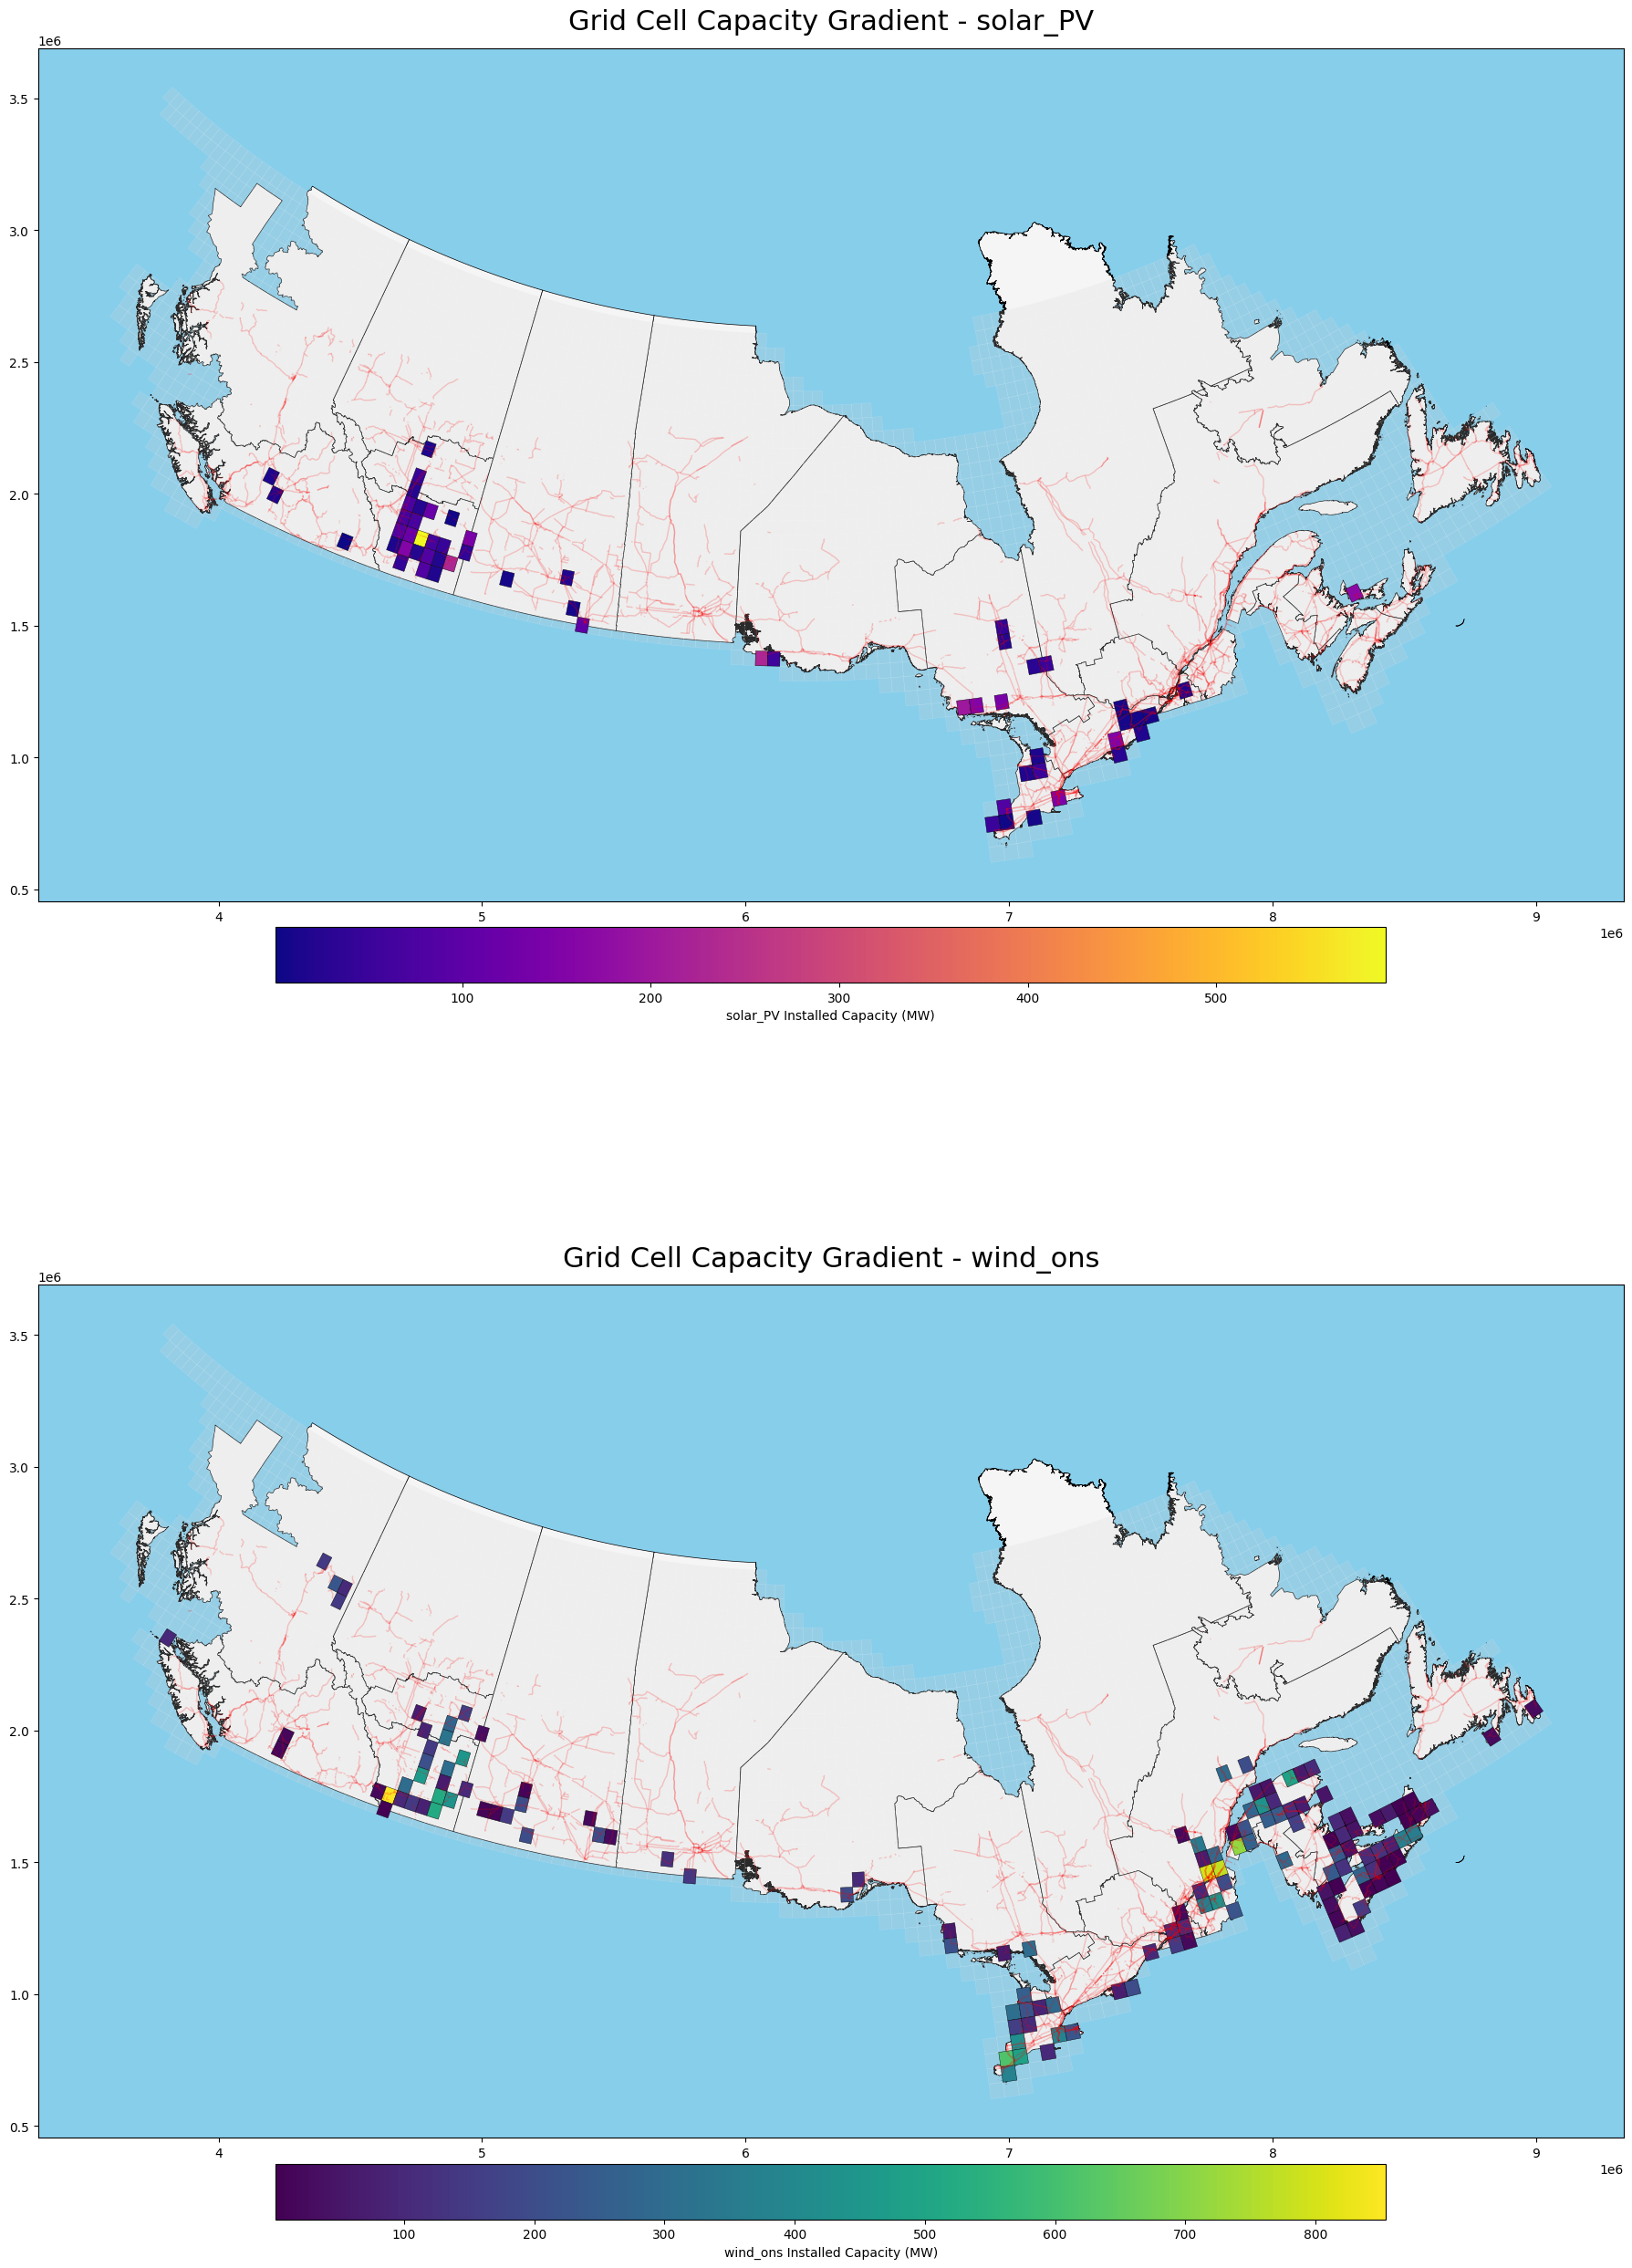

In [17]:
grouped_generators = generators.copy()
grouped_generators = grouped_generators.drop('geometry', axis=1)

fig, axes = plt.subplots(2, 1, figsize=(18, 28))

# Map generator types to their specific names and colormaps
tech_config = {
    'solar_PV': {'title': 'solar_PV', 'cmap': 'plasma'},
    'wind_ons': {'title': 'wind_ons', 'cmap': 'viridis'}
}

for ax, gen_type in zip(axes, tech_config):
    # Filter the generator dataframe for the current type
    df_filtered = grouped_generators[grouped_generators['gen_type'] == gen_type]
    
    # Aggregate capacity by grid cell for this specific type
    capacity_per_cell = df_filtered.groupby('grid_cell')['unit_installed_capacity'].sum().reset_index()
    
    # Merge with your spatial GeoDataFrame
    gridcells_with_capacity = gridcells.merge(capacity_per_cell, on='grid_cell', how='left')
    gridcells_with_capacity['unit_installed_capacity'] = gridcells_with_capacity['unit_installed_capacity'].fillna(0)
    
    # Set background color for the current subplot axis
    ax.set_facecolor('skyblue')
    
    # Plot base clusters
    clusters.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=0.5)
    
    # Separate active vs inactive cells for this generator type
    zero_capacity = gridcells_with_capacity[gridcells_with_capacity['unit_installed_capacity'] == 0]
    active_capacity = gridcells_with_capacity[gridcells_with_capacity['unit_installed_capacity'] > 0]
    
    # Plot inactive cells
    zero_capacity.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.3, alpha=0.2)
    
    # Plot the gradient for active cells
    config = tech_config[gen_type]
    if not active_capacity.empty:
        active_capacity.plot(
            ax=ax, 
            column='unit_installed_capacity', 
            cmap=config['cmap'], 
            edgecolor='black', 
            linewidth=0.3,
            legend=True,
            legend_kwds={
                'label': f"{config['title']} Installed Capacity (MW)", 
                'orientation': "horizontal", 
                'pad': 0.02,
                'shrink': 0.7  # Helps size the colorbar nicely relative to the plot
            }
        )
    
    # Plot transmission lines on top
    transmission_data.plot(ax=ax, color='red', linewidth=1, alpha=0.2)
    
    # Set specific subplot title
    ax.set_title(f"Grid Cell Capacity Gradient - {config['title']}", fontsize=22, pad=15)

# 3. Optimize layout to prevent overlap between subplots and save
plt.tight_layout()
plt.savefig(os.path.join(path, 'results', 'visualizations', 'stacked_capacity_gradient_maps.png'), dpi=300)

## New wind/solar resources: Grid cell filtering and selection
### Filtering out offshore cells
The first step is identifying cells which lie outside of the Canadian land borders (i.e. offshore/USA).

In [18]:
# Combining the different clusters into a single shape for ease of processing
if os.path.exists(os.path.join(data_path, 'map_files', 'canada_bounds.tif')):
    print('Canada map bounds already calculated, skipping')

    with rasterio.open(os.path.join(data_path, 'map_files', 'canada_bounds.tif')) as src:
        # 2. Read the first band as a NumPy array
        mask = src.read(1)
        
        # 3. Read important spatial metadata
        meta = src.meta          # Dictionary of dimensions, data type, CRS, etc.
        crs = src.crs            # Coordinate Reference System
        transform = src.transform # Affine transform (pixel to coordinate mapping)
else:
    canada_map = clusters.union_all()
    # This is used to transform the vectorized map into a raster map for faster filtering
    pixel_size = 1000

    # Getting bounds of Canada map
    minx, miny, maxx, maxy = canada_map.bounds
    width = int((maxx - minx) / pixel_size)
    height = int((maxy - miny) / pixel_size)
    transform = rasterio.transform.from_origin(minx, maxy, pixel_size, pixel_size)

    mask = features.rasterize([(canada_map, 1)],
                            out_shape=(height, width),
                            transform=transform,
                            fill=0,
                            all_touched=True,
                            dtype=np.uint8)
    # 4. Save to a GeoTIFF file
    with rasterio.open(
        os.path.join(data_path, 'map_files', 'canada_bounds.tif'),
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype=mask.dtype,
        crs='EPSG:3347',
        transform=transform,
        nodata=0 # Optional
    ) as dst:
        dst.write(mask, 1)

Canada map bounds already calculated, skipping


This monte carlo function generates random points within each gridcell and checks if the point lies within the boundaries of the land borders. The points that lie within are divided by the total number of points to estimate the area of the gridcell that overlaps the map of Canada.

In [19]:
def monte_carlo_overlap(cell_geom, mask, transform, num_points=1000):
    minx, miny, maxx, maxy = cell_geom.bounds
    random_x = np.random.uniform(minx, maxx, num_points)
    random_y = np.random.uniform(miny, maxy, num_points)

    cols, rows = ~transform * (random_x, random_y)
    cols = cols.astype(int)
    cols = cols.astype(int)

    valid = (cols >= 0) & (cols < mask.shape[1]) & (rows >= 0) & (rows < mask.shape[0])
    cols = cols[valid].astype(int)
    rows = rows[valid].astype(int)

    count_inside = np.sum(mask[rows, cols] == 1)
    return count_inside / num_points
# Applying the monte carlo function to the set of gridcells
gridcells['percent_in_canada'] = gridcells.geometry.apply(lambda geom: monte_carlo_overlap(geom, mask, transform, num_points=1000)).apply(pd.Series)
gridcells.head()

,geometry,point_geometry,poly_geometry,percent_in_canada
grid_cell,,,,
1,"POLYGON ((3788321.476 3503870.707, 3825323.408...",POINT (-139.375 59.5),"POLYGON ((-139.6875 59.25, -139.6875 59.75, -1...",0.0
2,"POLYGON ((3813781.869 3480298.222, 3850393.167...",POINT (-138.75 59.5),"POLYGON ((-139.0625 59.25, -139.0625 59.75, -1...",0.0
3,"POLYGON ((3777147.586 3440337.878, 3813781.869...",POINT (-138.75 59),"POLYGON ((-139.0625 58.75, -139.0625 59.25, -1...",0.0
4,"POLYGON ((3839472.655 3456977.047, 3875689.784...",POINT (-138.125 59.5),"POLYGON ((-138.4375 59.25, -138.4375 59.75, -1...",0.0
5,"POLYGON ((3803232.788 3416658.666, 3839472.655...",POINT (-138.125 59),"POLYGON ((-138.4375 58.75, -138.4375 59.25, -1...",0.0


#### Filtering based on distance to grid
Next, the onshore cells are filtered based on their distance to existing transmission infrastructure. A buffer zone/radius of 30km is applied to all of the lines in the Canvet dataset, and all cells which fall outside the buffer zone are removed. This is due to the large negative impact on LCOE caused by long distance transmission lines.

In [20]:
# Get rid of offshore cells
threshold = 0.33
filtered_gridcells = gridcells[gridcells.percent_in_canada >= threshold]

buffer_distance = 30000 # Distance in meters
# Draw buffer zone around lines and transformers
buffered_lines = transmission_data.geometry.buffer(buffer_distance).union_all()
# Check intersection with gridcells
filtered_gridcells['close_to_grid'] = filtered_gridcells.geometry.intersects(buffered_lines)
filtered_gridcells.head()

c:\Users\ndematos\envs\pypsa_canada_py312\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,geometry,point_geometry,poly_geometry,percent_in_canada,close_to_grid
grid_cell,,,,,
31,"POLYGON ((3688809.849 2804192.798, 3722093.756...",POINT (-133.125 54),"POLYGON ((-133.4375 53.75, -133.4375 54.25, -1...",0.382,False
38,"POLYGON ((3982959.25 3128581.369, 4015543.749 ...",POINT (-132.5 58),"POLYGON ((-132.8125 57.75, -132.8125 58.25, -1...",0.487,False
39,"POLYGON ((3950348.045 3085121.421, 3982959.25 ...",POINT (-132.5 57.5),"POLYGON ((-132.8125 57.25, -132.8125 57.75, -1...",0.550,False
42,"POLYGON ((3721150.037 2779676.295, 3754005.3 2...",POINT (-132.5 54),"POLYGON ((-132.8125 53.75, -132.8125 54.25, -1...",0.676,False
43,"POLYGON ((3688251.866 2735833.915, 3721150.037...",POINT (-132.5 53.5),"POLYGON ((-132.8125 53.25, -132.8125 53.75, -1...",0.774,False


#### Assigning cells to clusters
The remaining cells are then assigned to the cluster which is closest. The result is saved in a feather format for visualizations, and a human readable csv.

In [21]:
# Filtering out cells outside of the transmission buffer zone
filtered_gridcells = filtered_gridcells[filtered_gridcells.close_to_grid]

# Finding the nearest cluster to each gridcell point (faster?)
filtered_gridcells = gpd.GeoDataFrame(filtered_gridcells, geometry=filtered_gridcells.point_geometry, index=filtered_gridcells.index, crs='EPSG:4326').to_crs('EPSG:3347')
filtered_gridcells = gpd.sjoin_nearest(filtered_gridcells, clusters, how='left', distance_col='distance')
filtered_gridcells = gpd.GeoDataFrame(filtered_gridcells, geometry=filtered_gridcells.poly_geometry, index=filtered_gridcells.index, crs='EPSG:4326').to_crs('EPSG:3347')
filtered_gridcells = filtered_gridcells.drop(['point_geometry', 'poly_geometry'], axis=1)

# Saving filtered data
os.makedirs(os.path.join(path, 'results', 'visualization_data'), exist_ok=True)
filtered_gridcells.drop(['geometry'], axis=1).to_csv(os.path.join(path, 'results', 'filtered_gridcells.csv'))
filtered_gridcells.to_feather(os.path.join(path, 'results', 'visualization_data', 'filtered_gridcells.feather'))
filtered_gridcells.head()

,geometry,percent_in_canada,close_to_grid,cluster,distance
grid_cell,,,,,
84,"POLYGON ((3851144.479 2752784.389, 3882655.654...",0.476,True,BC_North,7380.143399
85,"POLYGON ((3819594.015 2708049.838, 3851144.479...",0.380,True,BC_North,0.000000
98,"POLYGON ((3946086.407 2819784.745, 3977085.265...",0.532,True,BC_North,0.000000
99,"POLYGON ((3915052.608 2774851.774, 3946086.407...",0.735,True,BC_North,540.085951
100,"POLYGON ((3883981.966 2729865.458, 3915052.608...",0.933,True,BC_North,310.409089


### Finding maximum capacity factors
The current iteration of the PyPSA-Canada-National model uses one representative cell for each of the clusters when it comes to new wind and solar development. Currently, an average annual capacity factor is taken by averaging over the single weather year the capacity factors are calculated for. The cell is then evaluated, either for the maximum or median value for that cluster. Wind and solar profiles are evaluated separately.

In [22]:
output_solar = os.path.join(path, 'results', "max_cfs_solar.csv")
output_wind = os.path.join(path, 'results', "max_cfs_wind.csv")

# === CHARGER LA MAPPING GRID CELL -> BUS ===
mapping_df = filtered_gridcells.reset_index()
mapping_df = mapping_df[["grid_cell", "cluster"]].dropna()
mapping_df["grid_cell"] = mapping_df["grid_cell"]
grid_to_bus = mapping_df.set_index("grid_cell")["cluster"]
grid_to_bus.name = 'cluster'

In [23]:
def find_best_cell(all_profiles, grid_cells, label, option='max'):
    # Ensure that only the cells in the filtered set are included in the profiles
    common_cells = all_profiles.columns.intersection(grid_cells.index)
    all_profiles = all_profiles[common_cells]
   
    # Calculer la moyenne annuelle par cellule
    annual_avg = all_profiles.mean()
    annual_avg.name = 'avg_cf'
    grid_cells = pd.merge(grid_cells, annual_avg, how='right', right_index=True, left_index=True)
    grid_cells.to_csv(os.path.join(path, 'results', f'{label}_average_cf.csv'))
    
    match option:
        case 'max':
            best_indices = grid_cells.groupby('cluster')['avg_cf'].idxmax()
            grid_cells = grid_cells.loc[best_indices]
        case 'median':
            # To ensure we get a real row, we sort by 'avg_cf' and pick the middle index
            def get_middle(group):
                # Sort to ensure we pick the middle based on value
                sorted_group = group.sort_values('avg_cf')
                mid_idx = len(sorted_group) // 2
                return sorted_group.index[mid_idx]
            
            median_indices = grid_cells.groupby('cluster', group_keys=False).apply(lambda x: get_middle(x))
            grid_cells = grid_cells.loc[median_indices]
    # Construire le DataFrame de sortie
    output_df = pd.DataFrame()
    for grid_cell, data in grid_cells.iterrows():
        column_name = f"{data.cluster}_{label}-{grid_cell}"
        output_df[column_name] = all_profiles[grid_cell]
    return output_df

# === TRAITER LES PROFILS SOLAIRES ===
best_solar_cells = find_best_cell(solar_df, grid_to_bus, 'OPT_PV', 'median')
best_wind_cells = find_best_cell (wind_df, grid_to_bus, 'OPT_wind', 'median')
best_cells = pd.concat([best_solar_cells, best_wind_cells], axis=1)
best_cells.head()

C:\Users\ndematos\AppData\Local\Temp\ipykernel_6532\168348726.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_indices = grid_cells.groupby('cluster', group_keys=False).apply(lambda x: get_middle(x))
C:\Users\ndematos\AppData\Local\Temp\ipykernel_6532\168348726.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_indices = grid_cells.groupby('cluster', group_keys=False).apply(lambda x: get_middle(x)

,AB_Central_OPT_PV-780,AB_North_OPT_PV-533,AB_South_OPT_PV-676,BC_North_OPT_PV-379,BC_South_OPT_PV-542,MB_OPT_PV-1198,NB_East_OPT_PV-2505,NB_West_OPT_PV-2443,NL_Labrador_OPT_PV-2630,NL_Newfoundland_OPT_PV-2974,...,ON_North_OPT_wind-1798,ON_Northwest_OPT_wind-1463,ON_South_OPT_wind-1812,ON_Toronto_OPT_wind-1902,PE_OPT_wind-2707,QC_Central_OPT_wind-2385,QC_East_OPT_wind-2415,QC_North_OPT_wind-2048,QC_South_OPT_wind-2127,SK_OPT_wind-1042
2025-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.2020,0.2385,0.2045,0.2101,0.7923,0.5211,0.5157,0.4643,0.4938,0.0539
2025-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.2252,0.2611,0.2275,0.2318,0.8222,0.5302,0.5250,0.4617,0.4914,0.0425
2025-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.2513,0.2846,0.2528,0.2557,0.8782,0.5403,0.5363,0.4575,0.4883,0.0321
2025-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.2633,0.2916,0.2641,0.2647,0.8936,0.5486,0.5466,0.4559,0.4865,0.0258
2025-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.2580,0.2822,0.2583,0.2574,0.9109,0.5487,0.5487,0.4494,0.4787,0.0294


### Saving results
Finally, the set of expandable generators is created, merged with the existing generators and the files are saved into the model folder.

In [24]:
# Creating expandable generators
expandable_gens = pd.DataFrame()
expandable_gens['name'] = best_cells.columns
expandable_gens['bus'] = best_cells.columns.str.split('_OPT').str[0]
expandable_gens['model'] = best_cells.columns.str.split('OPT_').str[-1].str.split('-').str[0].map({'PV':'default_solar_PV', 'wind':'wind_new'})
expandable_gens['p_nom'] = 0
expandable_gens['p_nom_extendable'] = True
expandable_gens['build_year'] = 2030
expandable_gens = expandable_gens.set_index('name')

# Merging with existing, saving
gens = pd.concat([existing_generators, expandable_gens])
gens['group'] = 'ungrouped'
gens.index.name = 'name'
gens.head()
gens.to_csv(os.path.join(path, 'results', 'wind_solar_gens.csv'))

# Capacity factor data
all_profiles = pd.concat([filtered_cf_data, best_cells], axis=1)
all_profiles.head()
all_profiles.to_csv(os.path.join(path, 'results', 'wind_solar_cf.csv'))

## Visualizations
The following code is not necessary for running the model, it generates a map of the maximum cells used for each cluster.

In [25]:
# Max gridcells
df = pd.DataFrame()
df['wind'] = best_wind_cells.columns.str.split('-').str[-1].astype(int)
df['solar'] = best_solar_cells.columns.str.split('-').str[-1].astype(int)

# Extract sets of gridcell numbers for wind and solar
wind_cells = set(df['wind'].dropna().astype(str).unique())
solar_cells = set(df['solar'].dropna().astype(str).unique())

# Define function to classify each gridcell number
def classify_cell(cell_num):
    in_wind = cell_num in wind_cells
    in_solar = cell_num in solar_cells
    if in_wind and in_solar:
        return 'Both'
    elif in_wind:
        return 'Wind only'
    elif in_solar:
        return 'Solar only'
    else:
        return 'None'

filtered_gridcells['category'] = filtered_gridcells.index.to_series().apply(classify_cell)

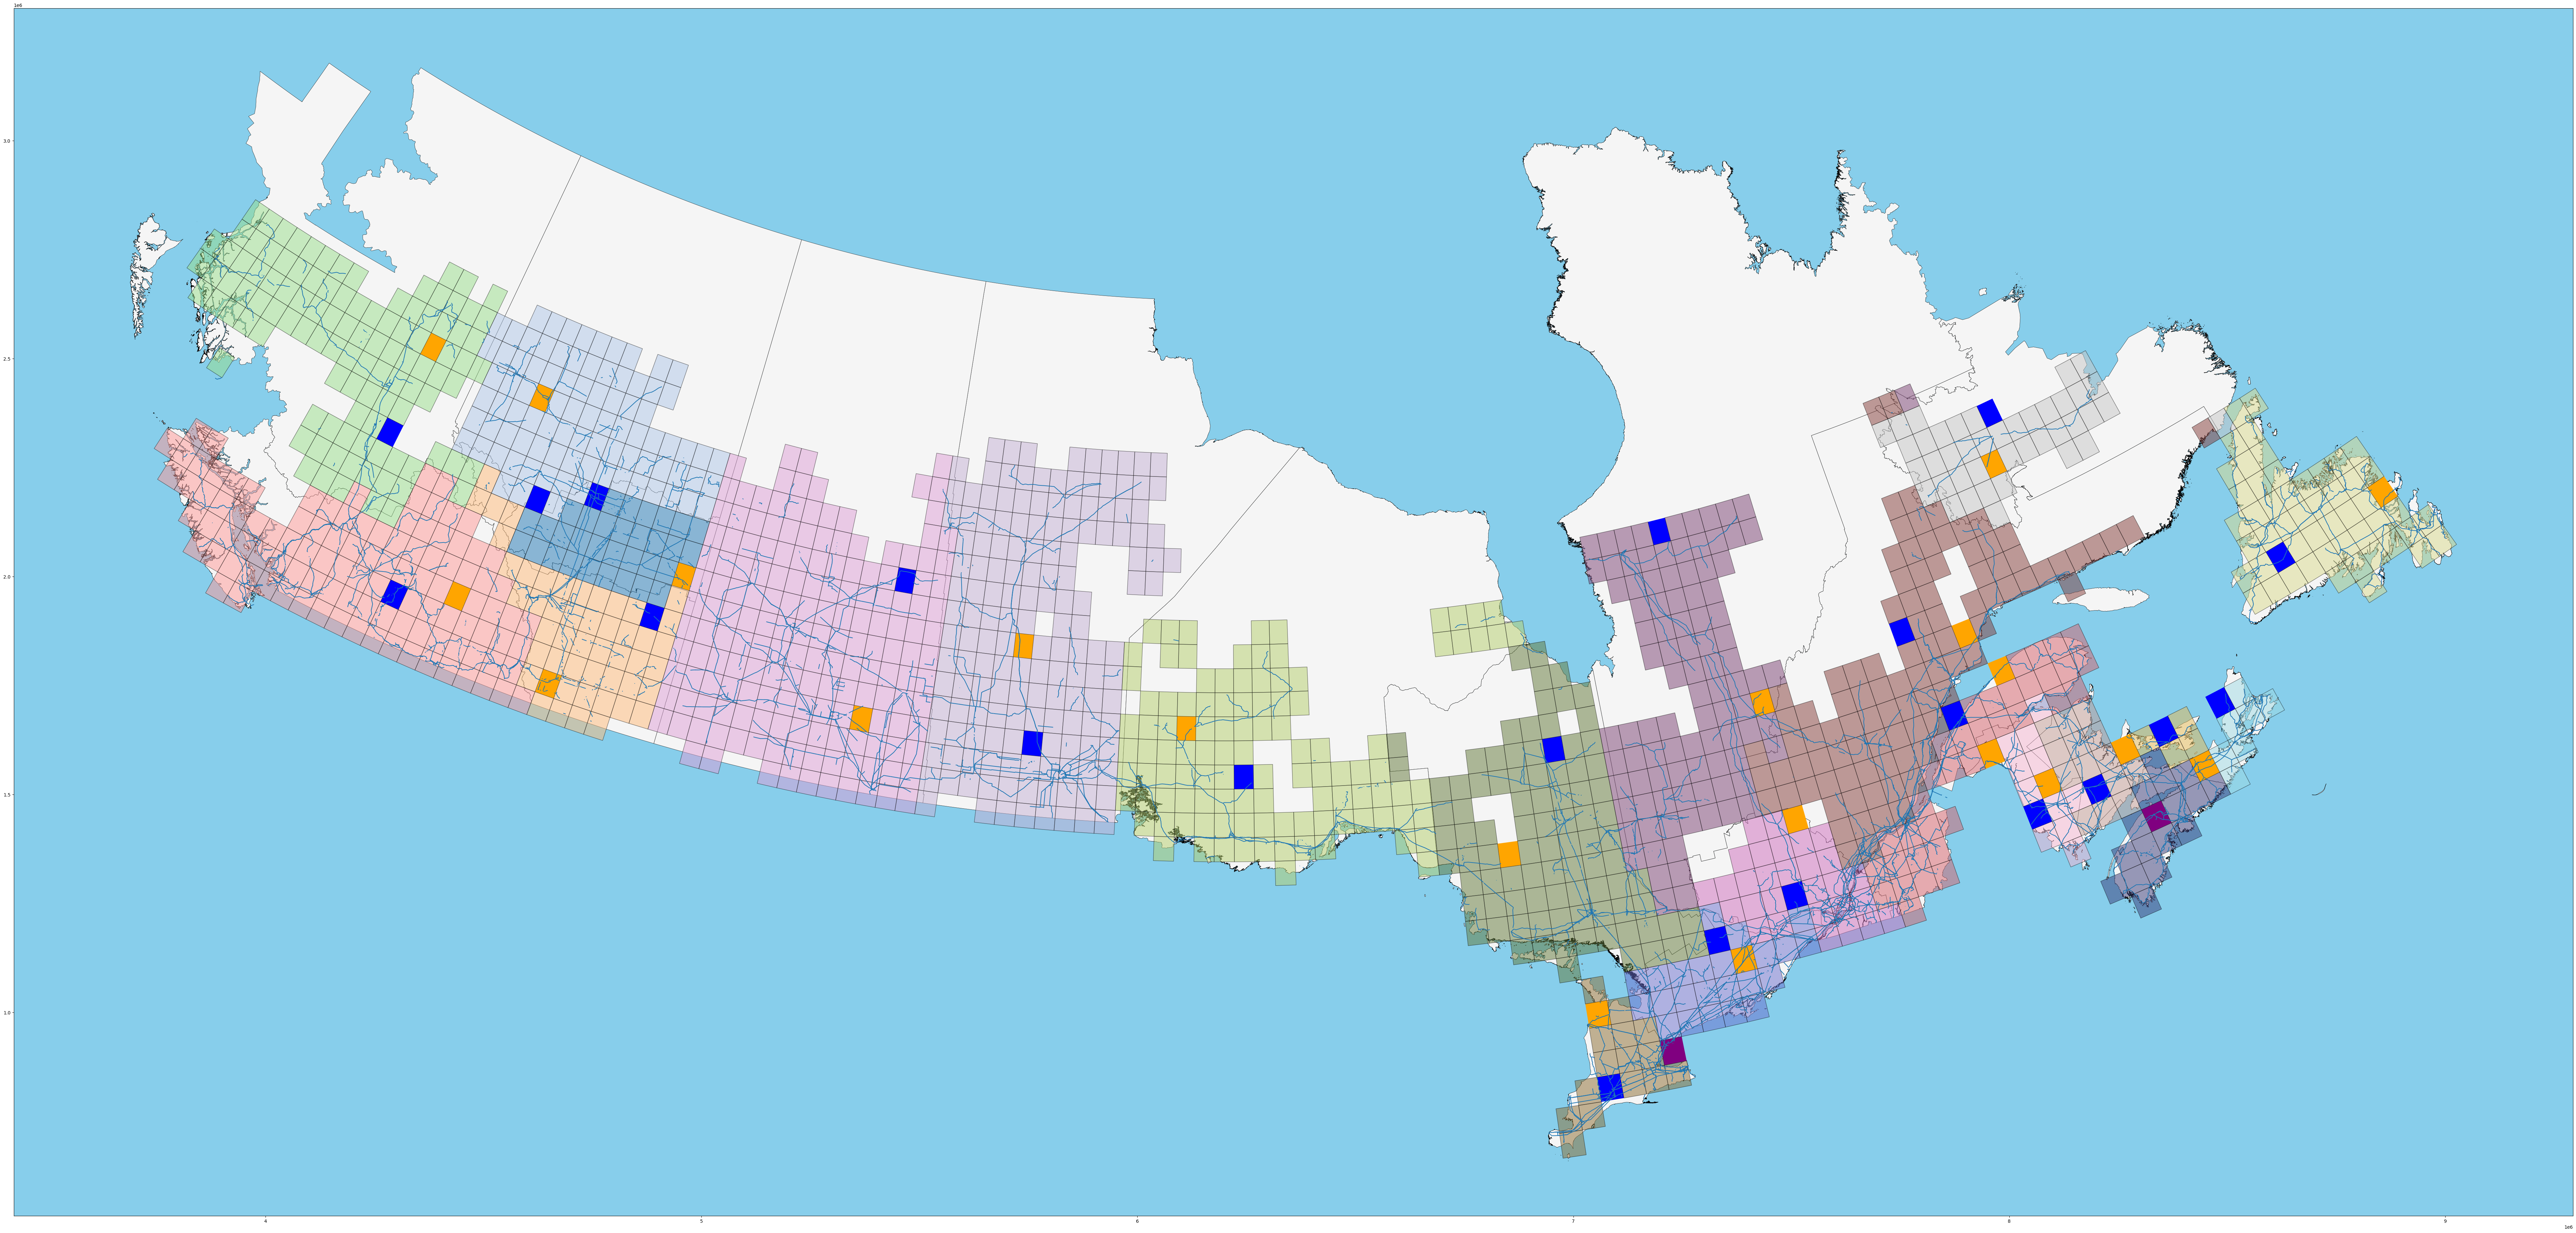

In [26]:
# Plot max gridcells
fig, ax = plt.subplots(figsize = (100,100))
ax.set_facecolor('skyblue')
clusters.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=0.5)

# Colours for the gridcells
fixed_colors = {
    'Both': 'purple',
    'Wind only': 'blue',
    'Solar only': 'orange'
}
colour_map = ListedColormap(plt.get_cmap('tab20').colors + plt.get_cmap('tab20b').colors)
unused_cells = filtered_gridcells[filtered_gridcells.category == 'None']

# plot the max cells
for category, colour in fixed_colors.items():
    subset = filtered_gridcells[filtered_gridcells.category == category]
    if not subset.empty:
        subset.plot(ax=ax, color=colour)
    
# plot the other cells
unused_cells.plot(ax=ax, column='cluster', cmap=colour_map, alpha=0.5, edgecolor='black')
transmission_data.plot(ax=ax)
plt.savefig(os.path.join(path, 'results', 'visualizations', 'filtered_gridcells.png'))
plt.show()